# Fit Metrics

## Tabel

In [1]:
from weibull_fit_metrics import run_metrics
run_metrics()

╭───────────┬────────────────────────────────────────┬────────┬────────┬─────────┬────────┬───────────┬────────╮
│ Datasæt   │ Årsag                                  │      n │     R² │    RMSE │    MAE │   KS-stat │   KS-p │
├───────────┼────────────────────────────────────────┼────────┼────────┼─────────┼────────┼───────────┼────────┤
│ Samlet    │ Alle                                   │ 233980 │   0.97 │ 1414.77 │ 713.83 │      0.05 │   0.00 │
│ Samlet    │ Alm.slid uden restværdi                │  75380 │   0.91 │  660.63 │ 384.12 │      0.07 │   0.00 │
│ Samlet    │ BTS fejl uden restværdi                │  22298 │   0.91 │  220.66 │ 112.19 │      0.08 │   0.00 │
│ Samlet    │ Beholdningsnedskrivning uden restværdi │    141 │   0.86 │    5.50 │   3.37 │      0.08 │   0.32 │
│ Samlet    │ Bortkommet med restværdi               │  19840 │   0.57 │  302.11 │ 187.66 │      0.12 │   0.00 │
│ Samlet    │ Fejlopmærkning                         │     59 │   0.78 │   11.50 │   8.57 │     

### Forklaringer:

##### $R^2$ 
Hvor meget af variationen i det observerede histogram forklarer modellen. $1.0$ er perfekt fit, under $0.7$ er dårligt. 

$R^2$ er ikke helt naturlig for fordelinger, så bruges som en indikator snarere end en absolut sandhed.

##### RMSE (Root Mean Squared Error) 
Gennemsnitlig afstand mellem observeret og forventet antal per bin, målt i antal stykker tøj. En RMSE på 50 betyder at modellen i gennemsnit rammer $\approx50$ stykker ved siden af per bin. **Lavere er bedre**, men *skalaen afhænger af datasættets størrelse* — så **sammenlign kun RMSE på tværs af modeller med nogenlunde samme n**.

##### MAE (Mean Absolute Error) 
Samme idé som RMSE, men mindre følsom overfor enkelte bins der er meget langt fra. **Hvis RMSE er meget højere end MAE er der nogle få bins hvor modellen fejler kraftigt.**

##### KS-stat (Kolmogorov-Smirnov statistik) 
Maksimal afstand mellem den empiriske CDF og den fittede Weibull CDF. **Tættere på 0 er bedre.**

##### KS-p 
P-værdien for KS-testen. **En høj p-værdi (> 0.05) betyder at modellen ikke kan afvises som en god fit. En lav p-værdi (< 0.05) betyder at Weibull-fordelingen sandsynligvis ikke passer godt til dataen for den pågældende produkt/ kassationstype.**

## Ekstreme cases

### Negative $R^2$-værdier

##### Skjorte - Ødelagt af lommefyld uden restværdi

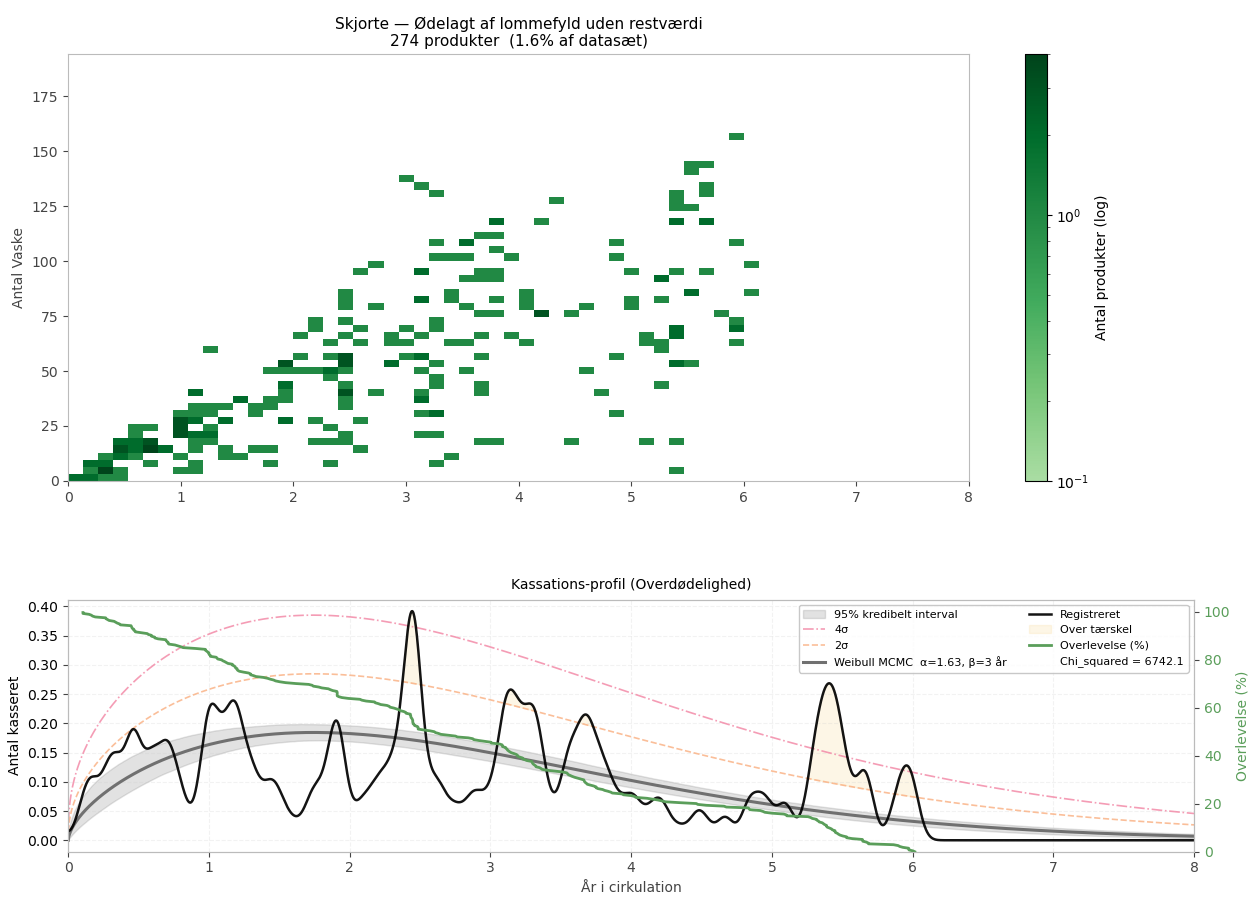

$$
R^2 = -0.3963 \quad \text{RMSE}=8.61 \quad \text{MAE}=6.81 \quad \text{KS}=0.0846 \quad \text{KS-p}=0.0414
$$

Disse er ikke direkte opslidte, men derimod ødelagt af lommefyld. Modellen er dårlig til disse typer, grundet de irregulære kassationsmønstre.

#### Bortkommet med restværdi

Det ses at både Skjorte, Shorts, Fleece og Forklæde har negativ $R^2$-værdi med kassationsårsagen "Bortkommet med restværdi", og alle med en KS-p $= 0,0000$. Disse er altså ikke slidt op, eller ødelagte, men blevet væk.

Vores Weibull-model er designet til at beskrive naturlig slitage over tid, men "bortkommet"-kassationer følger ikke dette mønster. De opstår højst sandsynligt af tilfældige eksterne hændelser uden sammenhæng med tekstilets alder og antal vaske. Det er derfor forventeligt, at modellen ikke passer godt her.

##### Skjorte - Bortkommet med restværdi

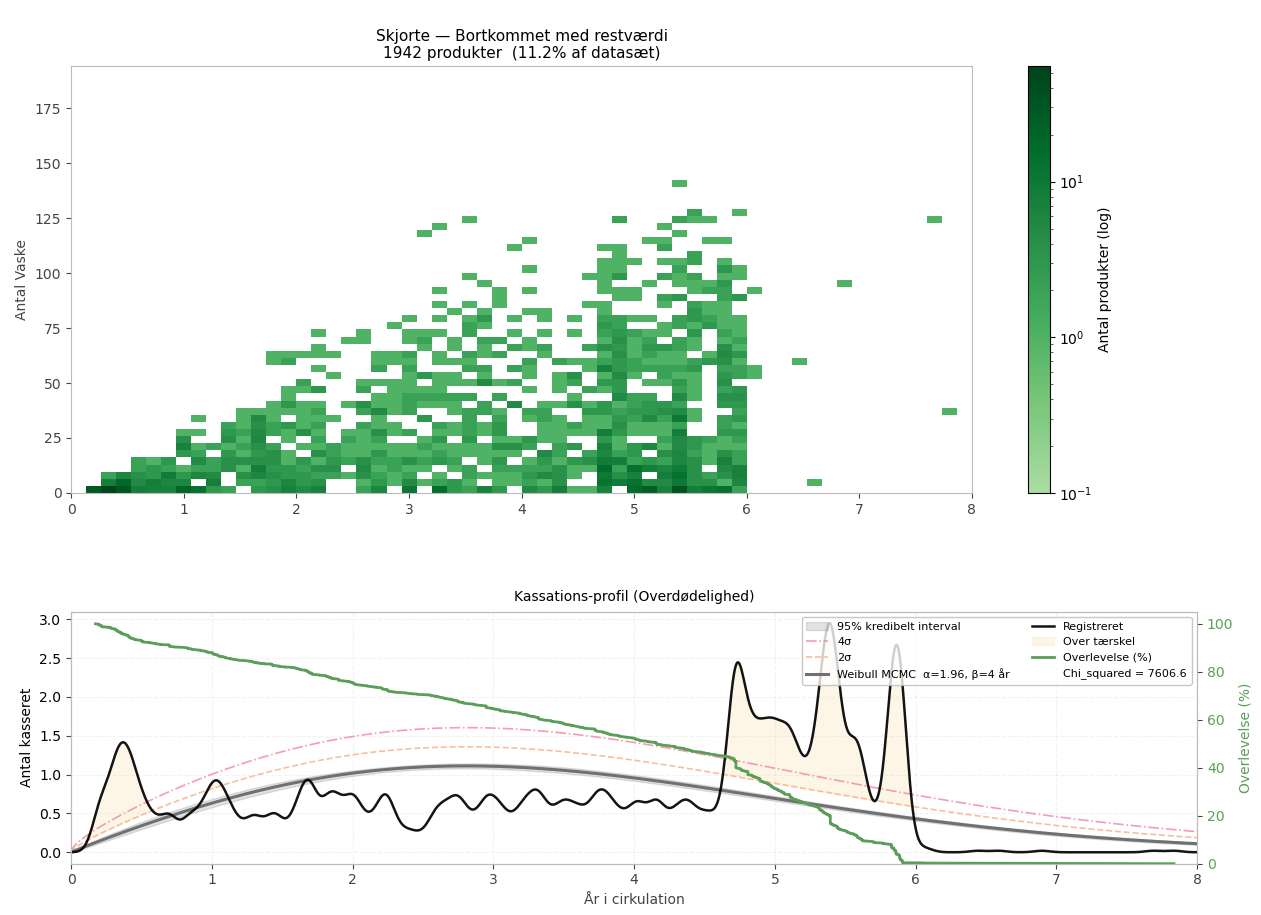

$$
R^2 = -0.69 \quad \text{RMSE}=35.52 \quad \text{MAE}=26.9 \quad \text{KS}=0.1878 \quad \text{KS-p}=0.0000
$$

##### Shorts - Bortkommet med restværdi

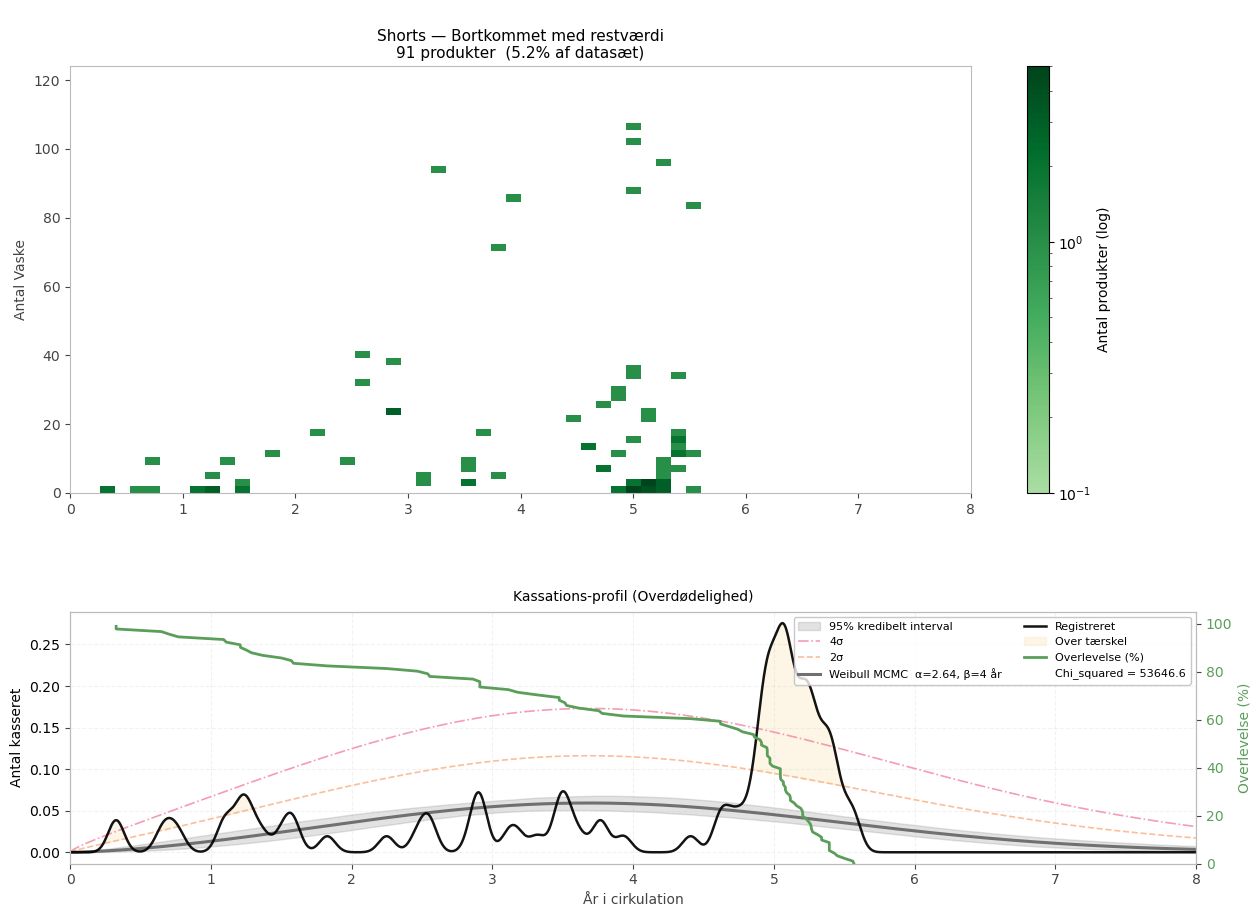

$$
R^2 = -0.0371 \quad \text{RMSE}=19.56 \quad \text{MAE}=17.25 \quad \text{KS}=0.2854 \quad \text{KS-p}=0.0000
$$

##### Fleece - Bortkommet med restværdi

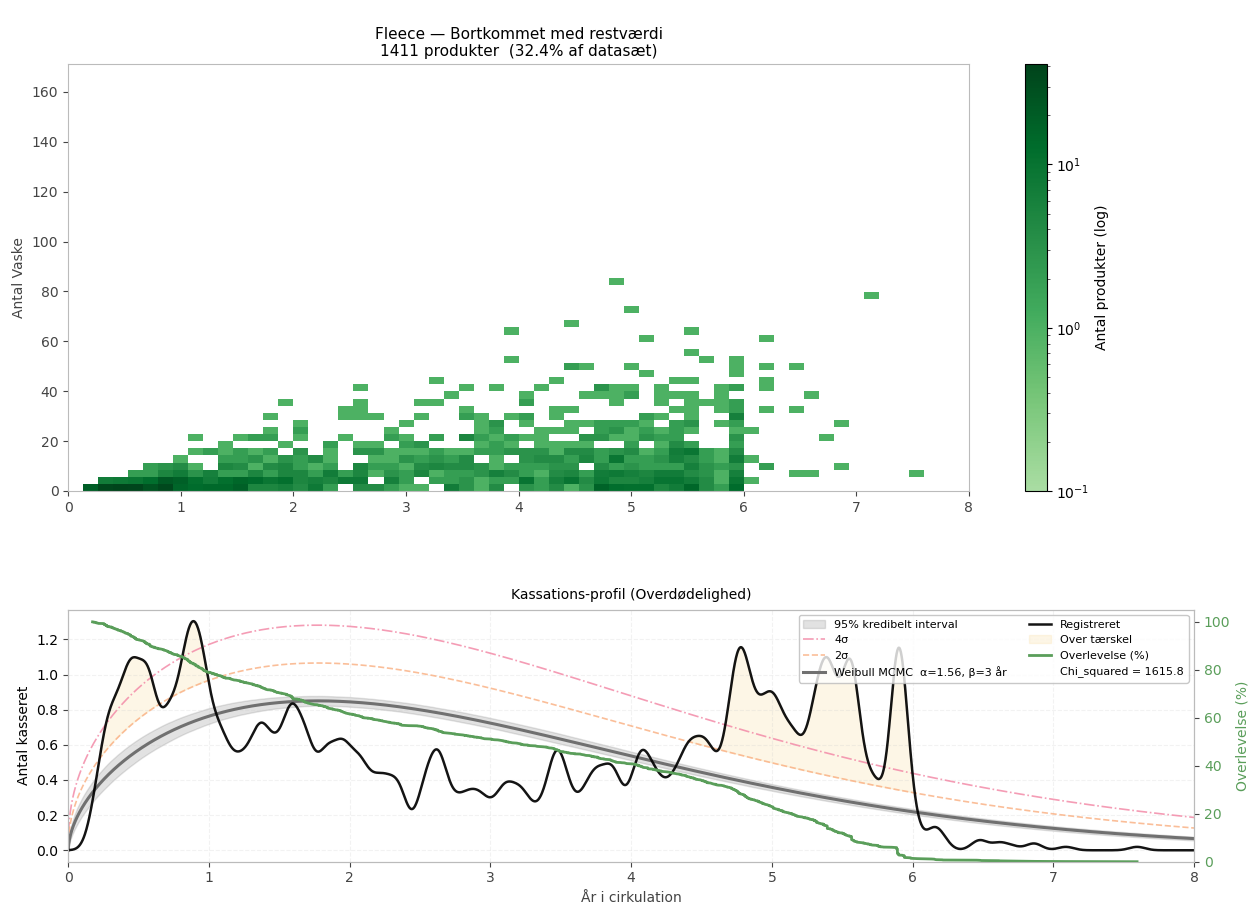

$$
R^2 = -0.0148 \quad \text{RMSE}=19.25 \quad \text{MAE}=15.49 \quad \text{KS}=0.1390 \quad \text{KS-p}=0.0000
$$

##### Forklæde - Bortkommet med restværdi

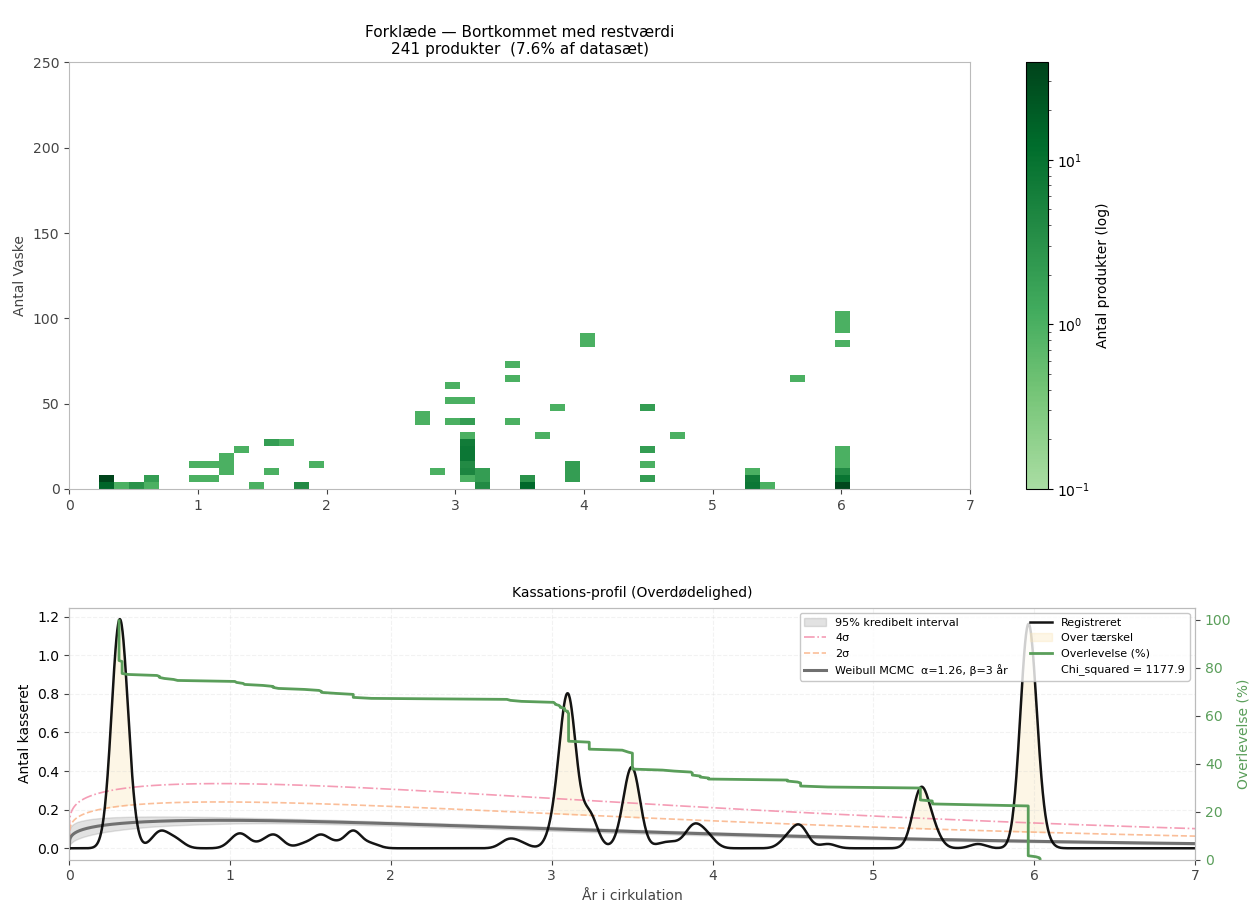

$$
R^2 = -0.0148 \quad \text{RMSE}=15.46 \quad \text{MAE}=19.09 \quad \text{KS}=0.2369 \quad \text{KS-p}=0.0000
$$

### Høje KS-stats

KS-statistikken måler den maksimale afstand mellem den empiriske fordelingsfunktion og den fittede Weibull-model. En høj KS-stat betyder altså, at der et sted i fordelingen er et stort spring mellem hvad modellen forudsiger og hvad data viser. Dette ses typisk i halen eller omkring et peak. 

KS-p $= 0$ betyder at denne afstand er statistisk umulig at forklare med tilfældig variation.

#### Produktfejl

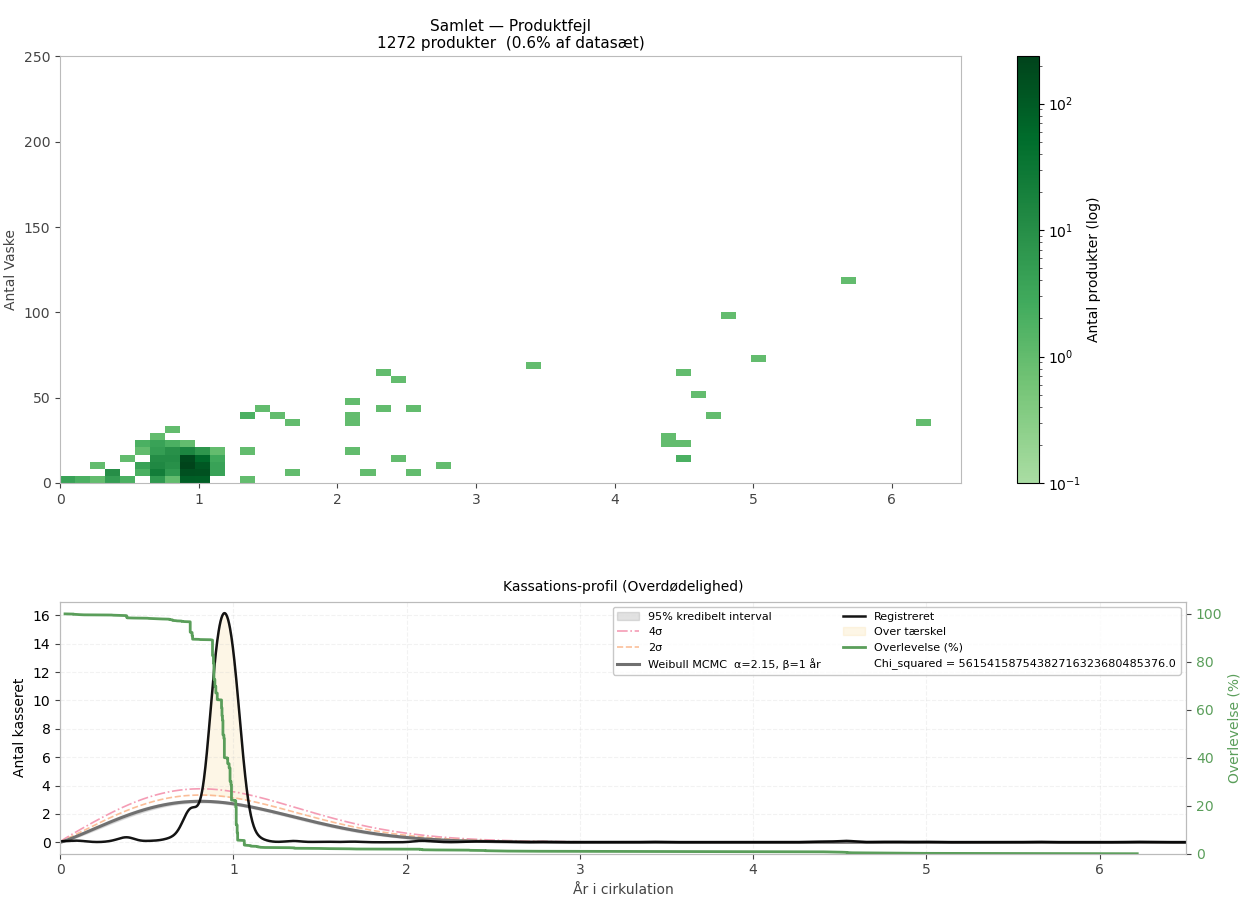

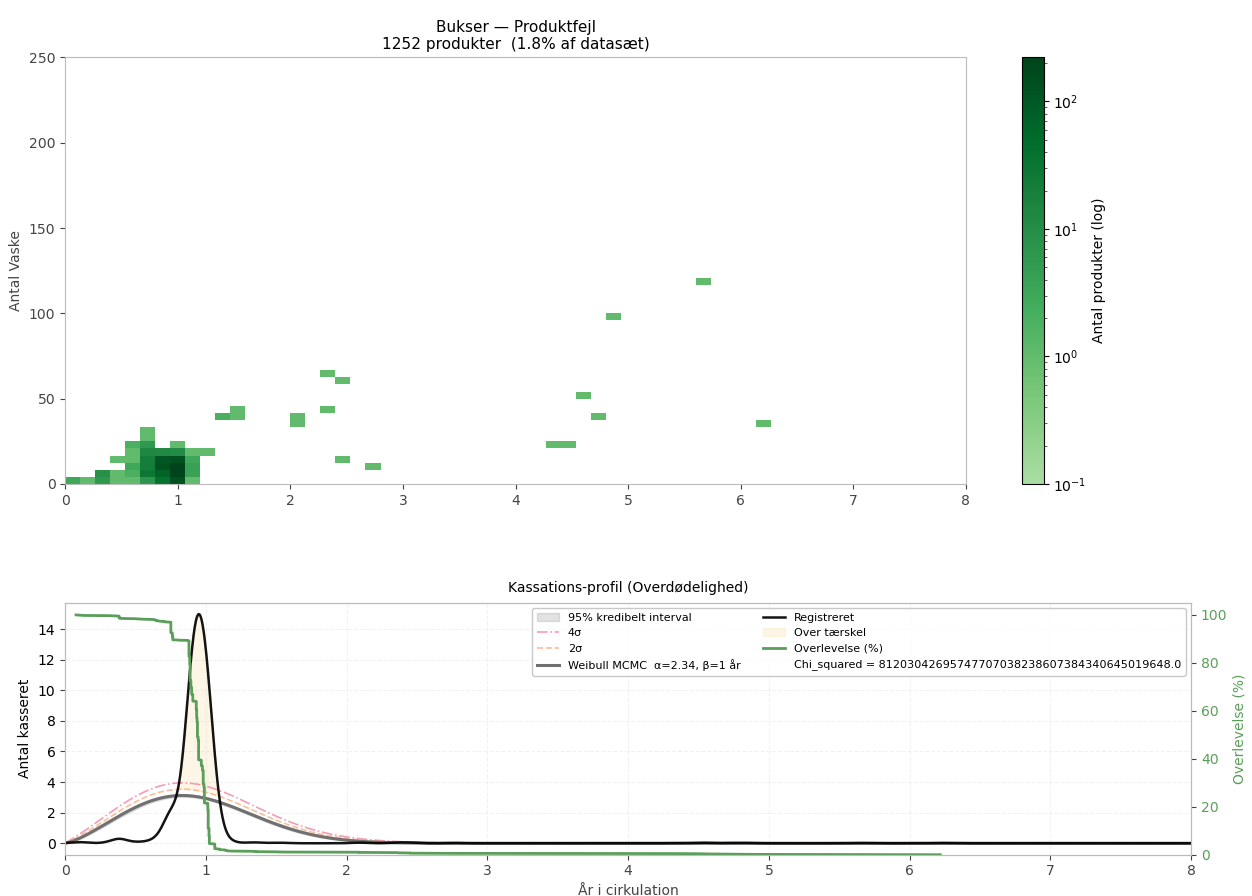

$$
R^2 = 0.2662  \quad \text{RMSE} = 94.7 \quad \text{MAE} = 30.29 \quad \text{KS} = 0.3666 \quad \text{KS-p} = 0.00 \ \text{og} \\
R^2 = 0.2591 \quad \text{RMSE} = 101.82 \quad \text{MAE} = 32.41 \quad \text{KS} = 0.3770 \quad \text{KS-p} = 0.00
$$

Samlet og Bukser har rimelig $R^2$ på $(\sim 0.26)$ men ekstrem KS-stat $(\sim 0.37)$. Det tyder på at Weibull-kurven fanger den overordnede trend, men fejler på fordelingens form, sandsynligvis fordi produktfejl opstår i klumper, hvilket vore model ikke kan håndtere.

Dette ses også ved de vanvittigt høje $\chi^2$-værdier

#### Meget små stikprøver

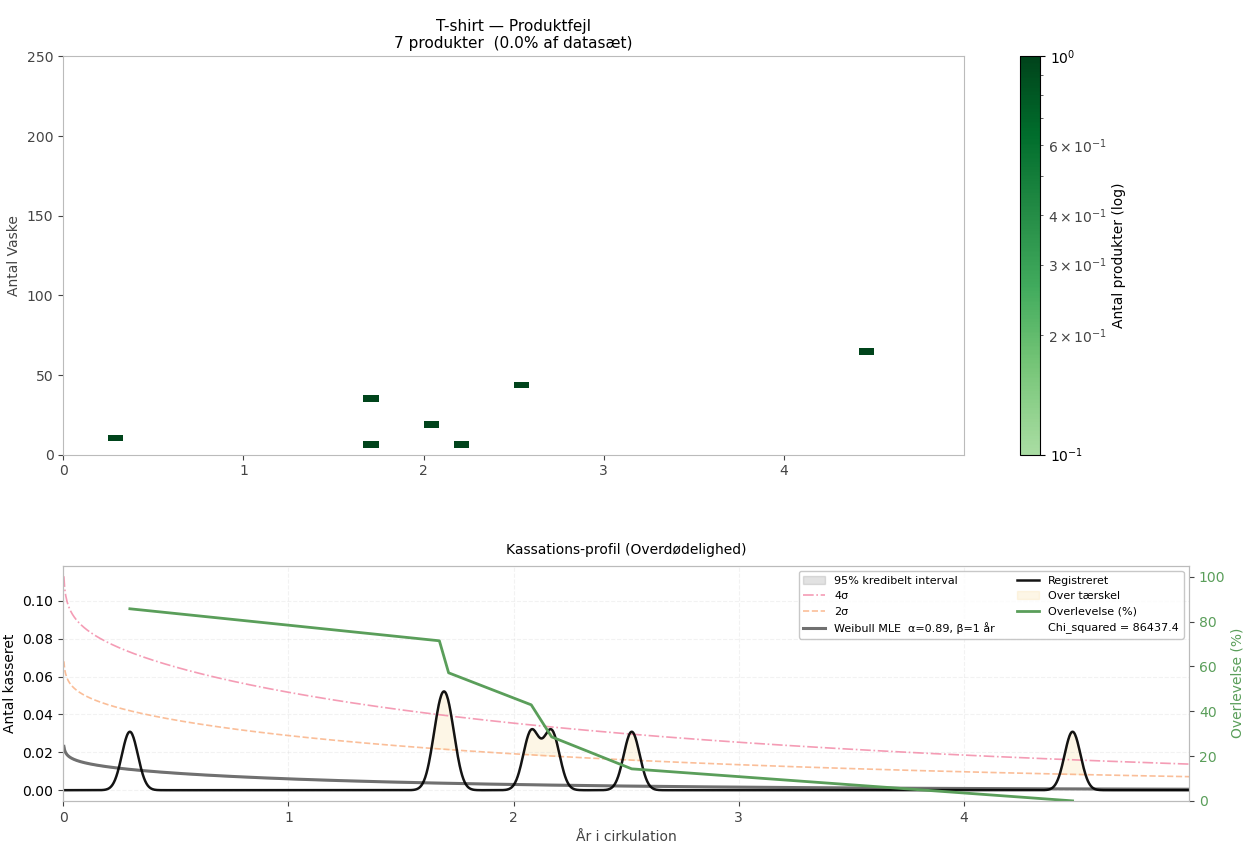

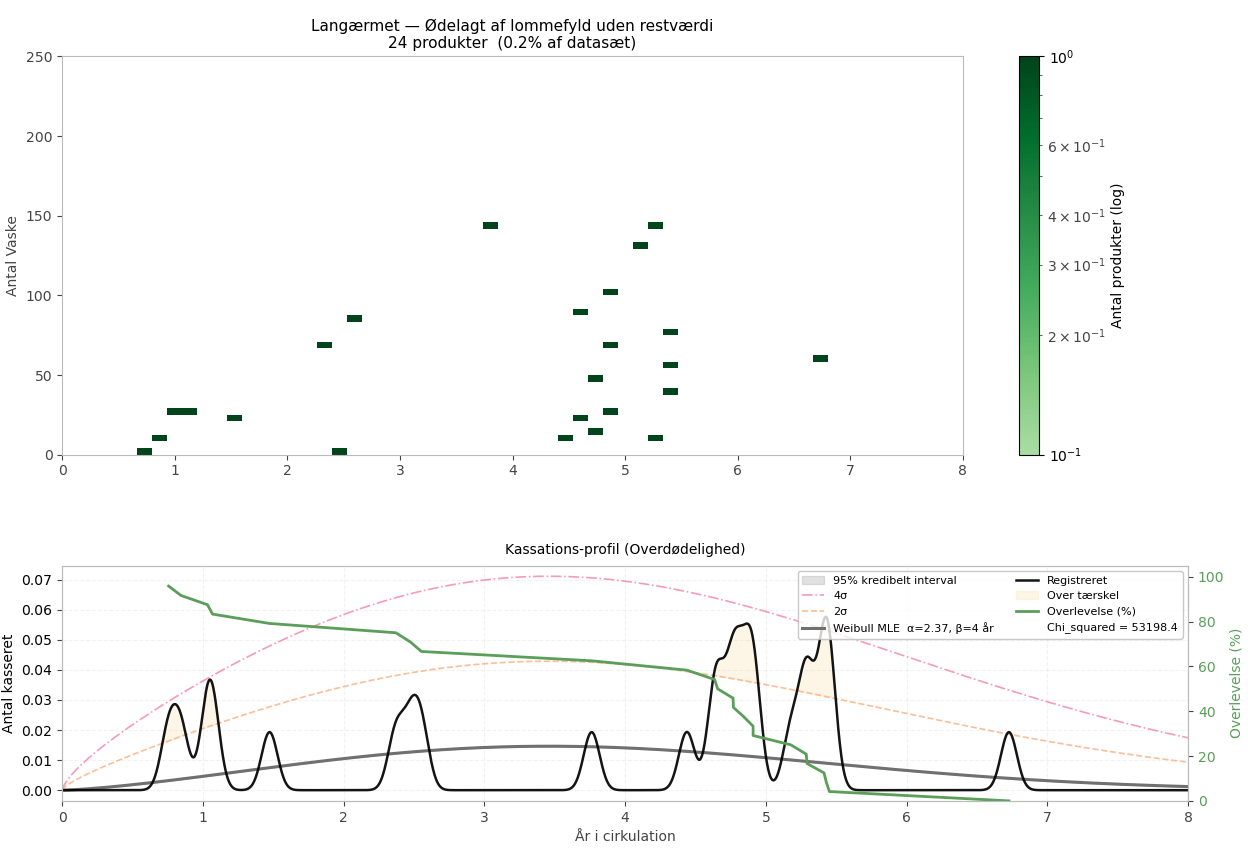

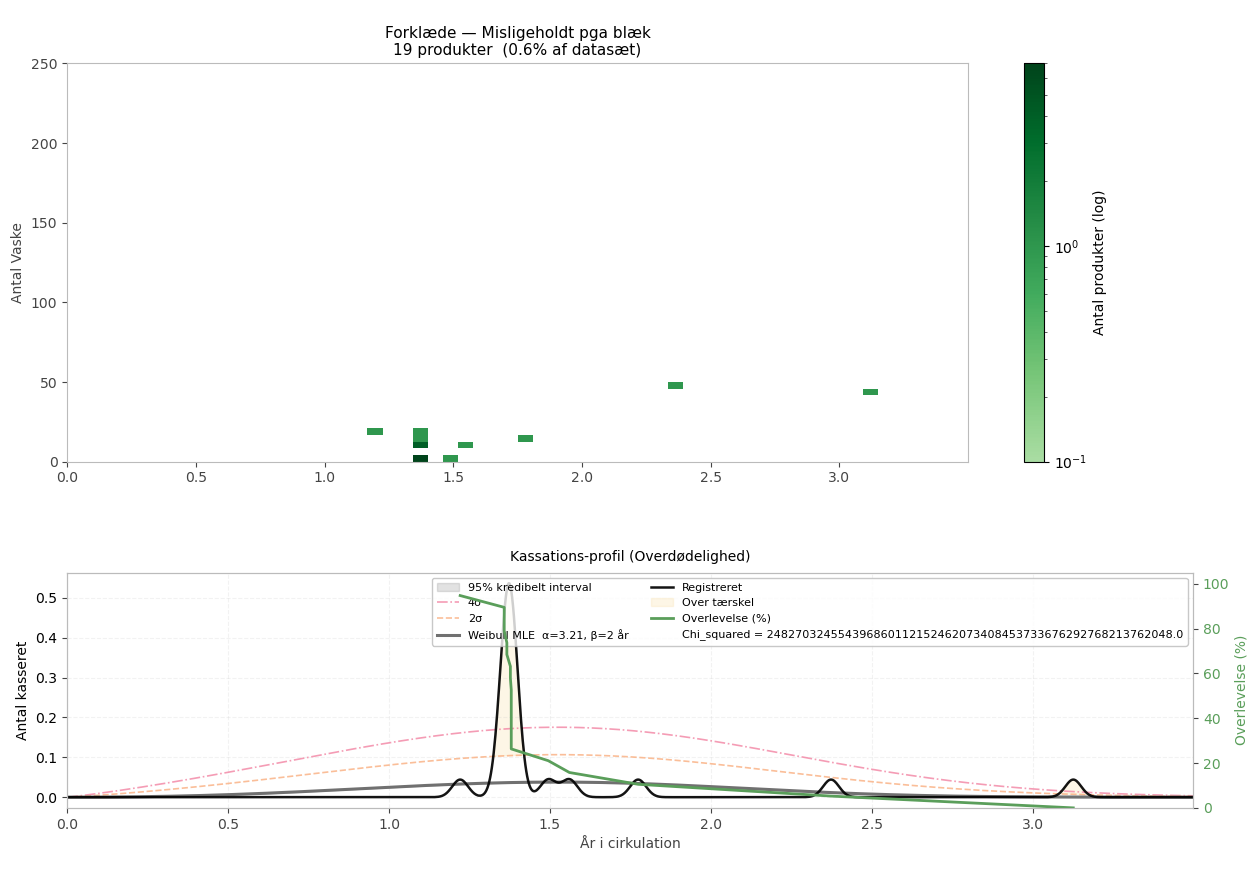

$$
R^2 = \text{NaN}  \quad \text{RMSE} = 4.29 \quad \text{MAE} = 4.29 \quad \text{KS} = 0.2907 \quad \text{KS-p} = 0.3048 \ \text{og} \\

R^2 = \text{NaN}  \quad \text{RMSE} = 7.54 \quad \text{MAE} = 7.54 \quad \text{KS} = 0.2833 \quad \text{KS-p} = 0.0342 \ \text{og} \\

R^2 = \text{NaN} \quad \text{RMSE} = 5.63 \quad \text{MAE} = 5.63 \quad \text{KS} = 0.3380 \quad \text{KS-p} = 0.0195
$$

T-shirts kasseret med produktfejl, langærmede kasseret med lommefyld og forklæder kasseret med blæk har alle tre meget små antal observationer $(n = 7^*, 24, 19)$ **Åbenbart ikke den samme som i tabellen*, hvorfor at $R^2$ ikke er meningsfuld, og KS-testen har lav power. Her er høj KS-stat måske et udtryk for datastøj, ikke nødvendigvis modelfejl.

#### Videresalg til kunder

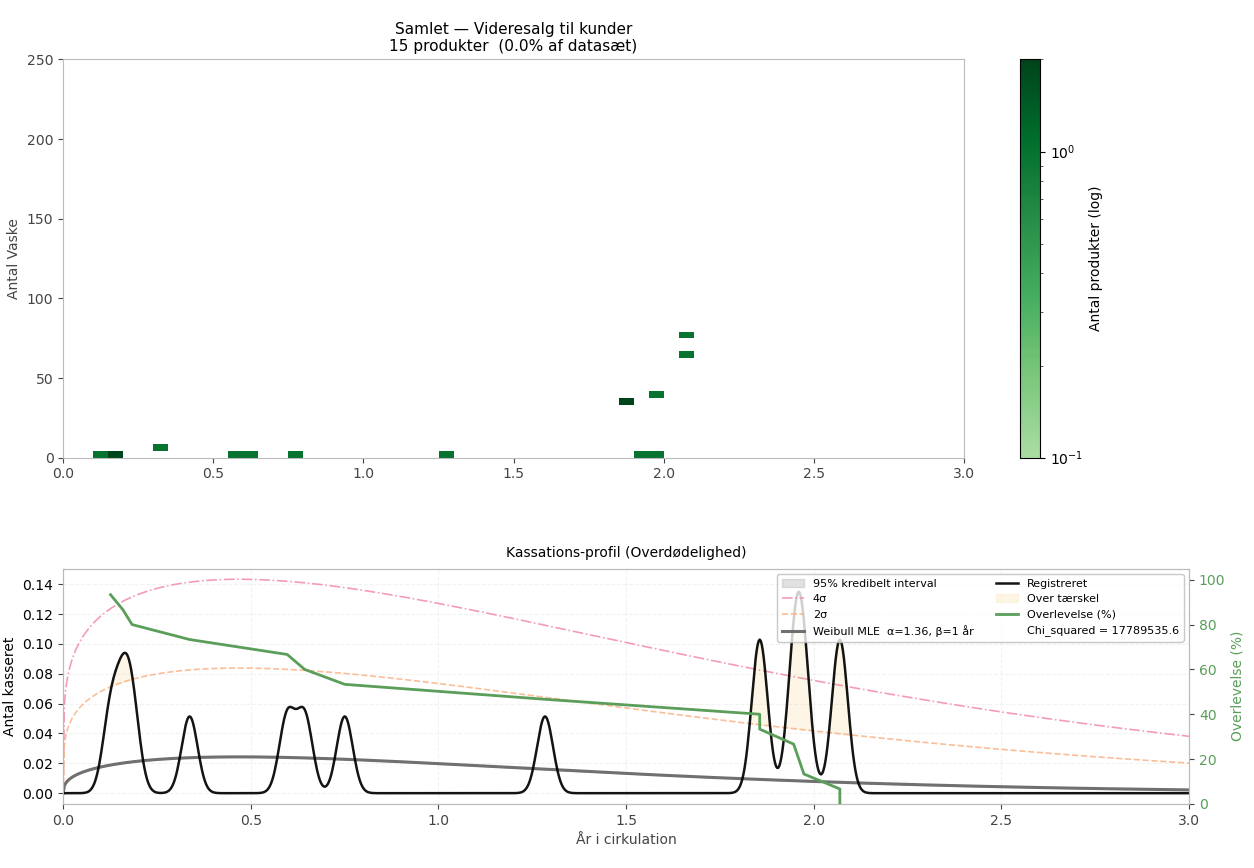

$$
R^2 = \text{NaN} \quad \text{RMSE} = 1.99 \quad \text{MAE} = 1.99 \quad \text{KS} = 0.2679 \quad \text{KS-p} = 0.1677
$$

Samlet kasseret grundet videresalg til kunder har en KS-pværdi på $0.1677$, altså ikke statistisk signifikant. Den høje KS-stat her er ikke bekymrende med de lille antal observationer, $n=15$, har testen simpelthen ikke styrke nok til at afvise noget.

## De tre værst fittede modeller

Disse tre modeller er dem som klarer sig dårligst ift. vores model.

De har alle tre både en $R^2$-værdi, som er mindre end $0.7$ og en KS-statistik på over $0.25$. Desuden er alle deres p-værdier til KS-statistikken på $0$

$$
\text{Samlet - Produktfejl} \\
n = 1304 \quad R^2 = 0.2662 \quad \text{RMSE} = 94.7 \quad \text{MAE} = 30.29 \quad \text{KS} = 0.3666 \quad \text{KS-p} = 0.0
$$

$$
\text{Bukser -  Produktfejl} \\
n = 1281 \quad R^2 = 0.2591 \quad \text{RMSE} = 101.82 \quad \text{MAE} = 32.41 \quad \text{KS} = 0.3770 \quad \text{KS-p} = 0.0
$$

$$
\text{Shorts - Bortkommet med restværdi} \\
n = 92 \quad R^2 = -0.0371 \quad \text{RMSE} = 19.56 \quad \text{MAE} = 17.25 \quad \text{KS} = 0.2854 \quad \text{KS-p} = 0.0
$$